# Off-resonance from a multi-echo train

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrutils/blob/main/examples/field_map.ipynb)

`field_map`: the B0 map a distortion or deblurring correction is driven from,
and the echo spacing that decides the range it can carry.

In [1]:
try:
    import mrutils  # noqa: F401
except ImportError:
    %pip install -q "mrutils[torch]" matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mrutils as mru


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


n = 128
image = phantom(n)
support = image > 1e-6

# A smooth off-resonance, of the shape a shim leaves behind: a linear term
# across the object and a quadratic one through it.
y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
truth = (110.0 * x + 40.0 * y**2 - 30.0 * x * y) * support  # Hz

echo_times = np.array([0.0020, 0.0042, 0.0064])  # seconds
print(f"dTE {1e3 * np.diff(echo_times)[0]:.1f} ms, "
      f"so the map aliases beyond +/-{1 / (2 * np.diff(echo_times)[0]):.0f} Hz")
print(f"the field spans {truth[support].min():.0f} to {truth[support].max():.0f} Hz")

dTE 2.2 ms, so the map aliases beyond +/-227 Hz
the field spans -77 to 82 Hz


## The estimate

`field_map` takes the angle of the product of consecutive echoes, so a receive
phase common to every echo cancels and only what accrued between them is left.
The object below carries one, to make sure of it.

Smoothing is applied to that *product* rather than to the map, which is what
keeps a wrap from being averaged across.

In [3]:
rng = np.random.default_rng(0)


def echoes(field, level=0.01):
    """Complex images of one object at each echo time."""
    # A receive phase the object carries at every echo: the estimator must be
    # blind to it, because it is common to the pair it takes the angle of.
    receive = np.exp(1j * 0.7 * y)
    stack = np.stack([image * receive * np.exp(2j * np.pi * field * t) for t in echo_times])
    noise = rng.normal(size=stack.shape) + 1j * rng.normal(size=stack.shape)
    return stack + level * noise


estimated = mru.field_map(echoes(truth), echo_times)

residual = np.abs(estimated - truth)[support]
print(f"median error {np.median(residual):.2f} Hz, 95th percentile {np.percentile(residual, 95):.2f} Hz")

median error 0.48 Hz, 95th percentile 3.31 Hz


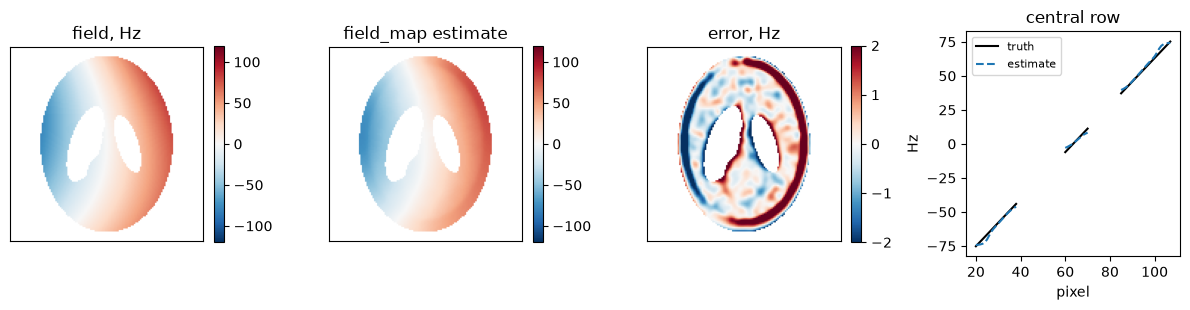

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
limits = dict(cmap="RdBu_r", vmin=-120, vmax=120)
shown = axes[0].imshow(np.where(support, truth, np.nan), **limits)
axes[0].set_title("field, Hz")
fig.colorbar(shown, ax=axes[0], fraction=0.046)

shown = axes[1].imshow(np.where(support, estimated, np.nan), **limits)
axes[1].set_title("field_map estimate")
fig.colorbar(shown, ax=axes[1], fraction=0.046)

shown = axes[2].imshow(np.where(support, estimated - truth, np.nan), cmap="RdBu_r", vmin=-2, vmax=2)
axes[2].set_title("error, Hz")
fig.colorbar(shown, ax=axes[2], fraction=0.046)
for axis in axes[:3]:
    axis.set_xticks([])
    axis.set_yticks([])

# Only inside the object: outside it there is no signal to take an angle of.
row = n // 2
inside = lambda values: np.where(support[row], values[row], np.nan)
axes[3].plot(inside(truth), color="k", label="truth")
axes[3].plot(inside(estimated), "--", label="estimate")
axes[3].set_title("central row")
axes[3].set_xlabel("pixel")
axes[3].set_ylabel("Hz")
axes[3].legend(fontsize=8)
fig.tight_layout()

In [5]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "field_map.png", dpi=110, bbox_inches="tight")

## What the echo spacing decides

A phase accrued between two echoes is only known modulo `2*pi`, so the echo
spacing sets the range the map can carry: `+/- 1 / (2 dTE)`. Beyond that the
estimate wraps, and no amount of smoothing recovers it — closing a field this
wide needs a shorter `dTE`, or an unwrapping step this package does not have.

That is a limit worth seeing rather than reading about.

38% of the object is past the alias limit


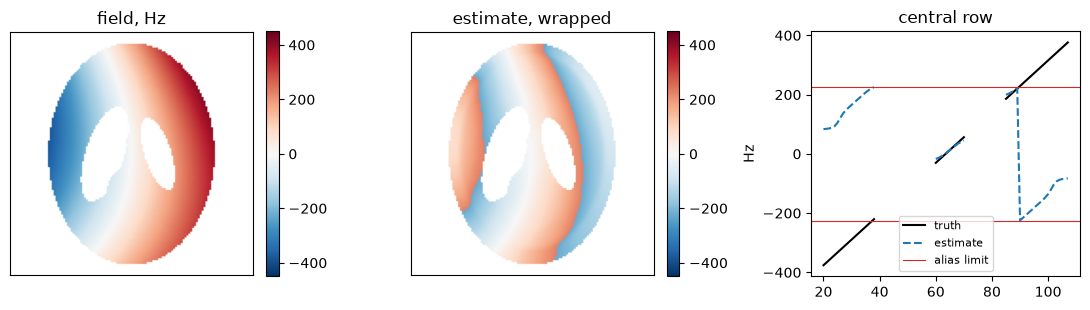

In [6]:
wide = 5.0 * truth  # now well past the +/-227 Hz the echo spacing allows
wrapped = mru.field_map(echoes(wide), echo_times)

limit = 1 / (2 * np.diff(echo_times)[0])
fraction = np.mean(np.abs(wide[support]) > limit)
print(f"{100 * fraction:.0f}% of the object is past the alias limit")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
shown = axes[0].imshow(np.where(support, wide, np.nan), cmap="RdBu_r", vmin=-450, vmax=450)
axes[0].set_title("field, Hz")
fig.colorbar(shown, ax=axes[0], fraction=0.046)
shown = axes[1].imshow(np.where(support, wrapped, np.nan), cmap="RdBu_r", vmin=-450, vmax=450)
axes[1].set_title("estimate, wrapped")
fig.colorbar(shown, ax=axes[1], fraction=0.046)
for axis in axes[:2]:
    axis.set_xticks([])
    axis.set_yticks([])

row = n // 2
inside = lambda values: np.where(support[row], values[row], np.nan)
axes[2].plot(inside(wide), color="k", label="truth")
axes[2].plot(inside(wrapped), "--", label="estimate")
axes[2].axhline(limit, color="tab:red", linewidth=0.8)
axes[2].axhline(-limit, color="tab:red", linewidth=0.8, label="alias limit")
axes[2].set_title("central row")
axes[2].set_ylabel("Hz")
axes[2].legend(fontsize=8)
fig.tight_layout()